# E04 — supprimer le one-hot

Un vecteur one-hot multiplié par `W` sélectionne une ligne de `W`.
Le produit matriciel fait donc 729 multiplications, dont 728 par zéro,
pour lire une ligne. On le remplace par une indexation directe.

In [1]:
words = open('names.txt', 'r').read().splitlines()

In [2]:
chars = sorted(list(set(''.join(words))))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [4]:
xs1, xs2, ys = [], [], []
for w in words:
    chs = ['.', '.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        xs1.append(stoi[ch1])
        xs2.append(stoi[ch2])
        ys.append(stoi[ch3])

xs = torch.tensor(xs1) * 27 + torch.tensor(xs2)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of exemples: ', num)

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((729, 27), generator=g, requires_grad=True)

number of exemples:  228146


## Les deux écritures sont équivalentes

In [5]:
xenc = F.one_hot(xs, num_classes=729).float()
print('memes logits :', torch.allclose(xenc @ W, W[xs]))
print('memoire du one-hot :', xenc.numel() * 4 / 1e6, 'Mo')
print('memoire de W[xs]   :', W[xs].numel() * 4 / 1e6, 'Mo')
del xenc

memes logits : True
memoire du one-hot : 665.273736 Mo
memoire de W[xs]   : 24.639768 Mo


In [6]:
%%timeit
logits = F.one_hot(xs, num_classes=729).float() @ W

55.2 ms ± 637 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [7]:
%%timeit
logits = W[xs]

666 μs ± 10.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Entraînement, sans one-hot

In [8]:
losses = []

for k in range(2001):
    logits = W[xs]
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(num), ys].log().mean()
    losses.append(loss.item())
    if k % 100 == 0:
        print(k, loss.item())

    W.grad = None
    loss.backward()

    W.data += -50 * W.grad

0 3.792776584625244
100 2.5085480213165283
200 2.3814938068389893
300 2.3280222415924072
400 2.297999620437622
500 2.278773307800293
600 2.26540470123291
700 2.255554676055908
800 2.247979164123535
900 2.2419605255126953
1000 2.237057685852051
1100 2.2329838275909424
1200 2.229543685913086
1300 2.22659969329834
1400 2.224050283432007
1500 2.221820831298828
1600 2.2198538780212402
1700 2.218104124069214
1800 2.2165372371673584
1900 2.2151246070861816
2000 2.2138445377349854


In [9]:
g = torch.Generator().manual_seed(2147483647)

for k in range(20):
    out = []
    ix1, ix2 = 0, 0
    while True:
        ctx = ix1 * 27 + ix2
        logits = W[[ctx]] # les crochets gardent la dimension de batch : (1, 27)
        counts = logits.exp()
        p = counts / counts.sum(1, keepdim=True)
        ix3 = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix3])
        if ix3 == 0:
            break
        ix1, ix2 = ix2, ix3
    print(''.join(out))

ce.
bra.
jalius.
rochityharlonimittain.
luwan.
ka.
da.
samiyah.
javer.
gotai.
moriellavorie.
teda.
kaley.
maside.
en.
aviony.
fobspihaniven.
tahlas.
kashrxdleenlen.
al.


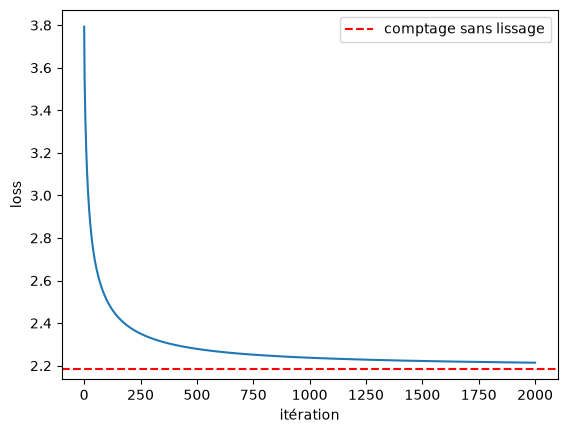

In [10]:
plt.plot(losses)
plt.axhline(2.1857, color='r', ls='--', label='comptage sans lissage')
plt.xlabel('itération'); plt.ylabel('loss'); plt.legend();